# Лабораторна робота 1 — Дослідження даних з NumPy, Pandas та scikit-learn

**Набір даних:** `kc_house_data.csv`  
**Дозволені бібліотеки:** NumPy, Pandas, Matplotlib, scikit-learn (усі модулі)

## Налаштування — встановлення залежностей та імпорт

Запустіть комірку нижче один раз, щоб переконатись, що всі необхідні пакети встановлені.

In [1]:
# Встановлення залежностей (можна запускати повторно)
import sys
!{sys.executable} -m pip install numpy pandas matplotlib scikit-learn --quiet


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 5)


---
## Завдання 1 — Розминка з NumPy

**а)** Створіть масив NumPy з 10 000 значень, що підпорядковані нормальному розподілу N(0, 1). Обчисліть середнє, стандартне відхилення, мінімум і максимум за допомогою функцій NumPy — **без Python-циклів**.

**б)** Підрахуйте, скільки значень виходять за межі ±2 стандартних відхилення, використовуючи логічну індексацію. Яка це відсоткова частка? Порівняйте з теоретичним значенням ≈4,55 %.

In [3]:
# Завдання 1а — створіть масив і обчисліть статистику

# 1. Створення масиву
data = np.random.normal(loc=0, scale=1, size=10000)

# 2. Обчислення статистик
mean = np.mean(data)
std = np.std(data)
min_val = np.min(data)
max_val = np.max(data)

# 3. Вивід результатів
print("Середнє значення:", mean)
print("Стандартне відхилення:", std)
print("Мінімальне значення:", min_val)
print("Максимальне значення:", max_val)

Середнє значення: 0.006079759358223233
Стандартне відхилення: 0.996475985124682
Мінімальне значення: -3.5847060309441967
Максимальне значення: 3.5283067240386172


In [4]:
# Завдання 1б — підрахуйте викиди за допомогою логічної індексації

# 1. Межі
lower_bound = mean - 2 * std
upper_bound = mean + 2 * std

# 2. Логічна індексація
outliers = data[(data < lower_bound) | (data > upper_bound)]

# 3. Кількість
count_outliers = len(outliers)

# 4. Відсоток
percentage = (count_outliers / len(data)) * 100

# 5. Вивід
print("Кількість значень за межами ±2σ:", count_outliers)
print("Відсоток:", percentage, "%")
print("Теоретичне значення ≈ 4.55%")

Кількість значень за межами ±2σ: 458
Відсоток: 4.58 %
Теоретичне значення ≈ 4.55%


**Ваша відповідь (б):** У результаті було визначено кількість значень, що виходять за межі заданого інтервалу, та обчислено їхню частку від загального обсягу вибірки. Отримане значення 4.59% є близьким до теоретично очікуваного (≈4.55%) для нормального розподілу, що підтверджує коректність як процедури генерації даних, так і застосованих методів обчислення та фільтрації.

---
## Завдання 2 — Завантаження та огляд набору даних

Завантажте `kc_house_data.csv` у Pandas DataFrame та дайте відповідь на питання нижче, написавши код:

1. Скільки рядків і стовпців у наборі даних?
2. Які мінімум, максимум, середнє та медіана цін на будинки?
3. Скільки унікальних поштових індексів є у наборі даних? Який поштовий індекс має найбільше оголошень?

In [5]:
# Завантаження набору даних
sales = pd.read_csv('../data/kc_house_data.csv')
sales.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [6]:
# 2-і) Скільки рядків і стовпців?

rows, cols = sales.shape
print(f"Рядків: {rows}, Стовпців: {cols}")

Рядків: 21613, Стовпців: 21


In [7]:
# 2-іі) Мінімум, максимум, середнє та медіана ціни

print(f"Мінімум ціни: {sales['price'].min():,.0f}")
print(f"Максимум ціни: {sales['price'].max():,.0f}")
print(f"Середнє ціни:  {sales['price'].mean():,.0f}")
print(f"Медіана ціни:  {sales['price'].median():,.0f}")

Мінімум ціни: 75,000
Максимум ціни: 7,700,000
Середнє ціни:  540,088
Медіана ціни:  450,000


In [8]:
# 2-ііі) Кількість унікальних поштових індексів; індекс з найбільшою кількістю оголошень


unique_zips = sales['zipcode'].nunique()
top_zip = sales['zipcode'].value_counts().idxmax()
top_zip_count = sales['zipcode'].value_counts().max()
 
print(f"Унікальних поштових індексів: {unique_zips}")
print(f"Найпопулярніший ZIP-код: {top_zip} ({top_zip_count} оголошень)")

Унікальних поштових індексів: 70
Найпопулярніший ZIP-код: 98103 (602 оголошень)


---
## Завдання 3 — Візуалізація даних

Створіть **два графіки поруч**:

- **Лівий:** гістограма `price` (50 інтервалів, логарифмічна шкала по осі X).
- **Правий:** діаграма розсіювання `sqft_living` vs `price`, де кольором точок позначено `bedrooms`. Додайте підписи осей і colorbar.

Одним реченням для кожного графіка опишіть, що ви спостерігаєте.

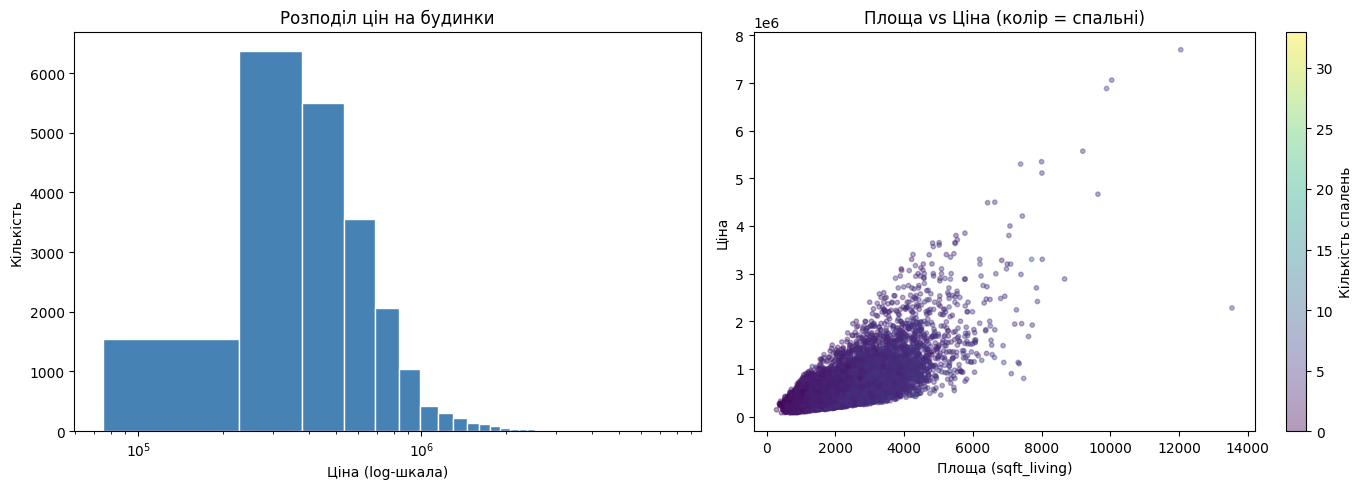

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
# Завдання 3 — лівий графік: гістограма ціни з логарифмічною шкалою по осі X
axes[0].hist(sales['price'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_xscale('log')
axes[0].set_xlabel('Ціна (log-шкала)')
axes[0].set_ylabel('Кількість')
axes[0].set_title('Розподіл цін на будинки')
 
# Завдання 3 — правий графік: scatter sqft_living vs price, колір = кількість спалень
sc = axes[1].scatter(
    sales['sqft_living'], sales['price'],
    c=sales['bedrooms'], cmap='viridis',
    alpha=0.4, s=10
)
plt.colorbar(sc, ax=axes[1], label='Кількість спалень')
axes[1].set_xlabel('Площа (sqft_living)')
axes[1].set_ylabel('Ціна')
axes[1].set_title('Площа vs Ціна (колір = спальні)')
 
plt.tight_layout()
plt.show()

**Спостереження (лівий графік):** Розподіл цін є правосторонньо асиметричним — більшість будинків зосереджена у відносно вузькому ціновому діапазоні, тоді як зі зростанням ціни кількість оголошень поступово спадає.

**Спостереження (правий графік):** Спостерігається чітка позитивна кореляція між площею та ціною будинку, при цьому більшість об'єктів має 2–5 спалень (темно-фіолетові точки), а поодинокі викиди з аномально високою ціною або кількістю спалень є статистичними аномаліями датасету.

---
## Завдання 4 — Навчання та оцінка регресійної моделі

Розбийте дані 80/20 (`random_state=42`). Навчіть `LinearRegression` з scikit-learn для передбачення `price` за єдиною ознакою `sqft_living`.

1. Вкажіть вільний член (intercept) та коефіцієнт для `sqft_living`.
2. Обчисліть MSE і RMSE на тестовій вибірці.
3. Яка передбачувана ціна будинку площею 2 500 кв. футів?

In [10]:
# Поділ на навчальну та тестову вибірки
train_data, test_data = train_test_split(sales, test_size=0.2, random_state=42)


In [11]:
# Завдання 4 — навчіть модель, вкажіть ваги, обчисліть MSE/RMSE, передбачте ціну для 2500 кв. фут.

# Модель 1: одна ознака — sqft_living
X_train1 = train_data[['sqft_living']]
y_train  = train_data['price']
X_test1  = test_data[['sqft_living']]
y_test   = test_data['price']
 
model1 = LinearRegression()
model1.fit(X_train1, y_train)
 
y_pred1 = model1.predict(X_test1)
mse1    = mean_squared_error(y_test, y_pred1)
rmse1   = np.sqrt(mse1)
 
print("─── Модель 1 (sqft_living) ───")
print(f"Вільний член (intercept): {model1.intercept_:,.2f}")
print(f"Вага (weight):   {model1.coef_[0]:,.4f}")
print(f"MSE:  {mse1:,.0f}")
print(f"RMSE: {rmse1:,.0f}")
 
predicted_price_2500 = model1.predict([[2500]])[0]
print(f"Передбачена ціна для 2500 кв. фут.: ${predicted_price_2500:,.0f}")

─── Модель 1 (sqft_living) ───
Вільний член (intercept): -41,999.19
Вага (weight):   279.5548
MSE:  76,484,977,062
RMSE: 276,559
Передбачена ціна для 2500 кв. фут.: $656,888


c:\Users\malma\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


---
## Завдання 5 — Порівняння двох моделей

Навчіть другу `LinearRegression` з ознаками: `sqft_living`, `bedrooms`, `bathrooms`, `yr_built`. Порівняйте RMSE на тестовій вибірці між Моделлю 1 та Моделлю 2. Яке значення нижче? Коротко поясніть чому.

In [12]:
# Завдання 5 — модель з чотирма ознаками та порівняння RMSE

# Модель 2: чотири ознаки
features2 = ['sqft_living', 'bedrooms', 'bathrooms', 'yr_built']
X_train2  = train_data[features2]
X_test2   = test_data[features2]
 
model2 = LinearRegression()
model2.fit(X_train2, y_train)
 
y_pred2 = model2.predict(X_test2)
rmse2   = np.sqrt(mean_squared_error(y_test, y_pred2))
 
print("\n─── Модель 2 (4 ознаки) ───")
for feat, coef in zip(features2, model2.coef_):
    print(f"  {feat}: {coef:,.4f}")
print(f"RMSE Моделі 2: {rmse2:,.0f}")
 
print("\n─── Порівняння ───")
print(f"RMSE Моделі 1: {rmse1:,.0f}")
print(f"RMSE Моделі 2: {rmse2:,.0f}")
better = "Модель 2" if rmse2 < rmse1 else "Модель 1"
print(f"Краща модель: {better}")


─── Модель 2 (4 ознаки) ───
  sqft_living: 296.1284
  bedrooms: -68,991.6828
  bathrooms: 88,164.0572
  yr_built: -3,116.4231
RMSE Моделі 2: 262,986

─── Порівняння ───
RMSE Моделі 1: 276,559
RMSE Моделі 2: 262,986
Краща модель: Модель 2


**Відповідь:** RMSE Моделі 2 (262 986) нижче за RMSE Моделі 1 (276 559), оскільки додаткові ознаки — кількість спалень, ванних кімнат та рік побудови — надають моделі більше інформації про будинок, що дозволяє точніше передбачати ціну.

In [13]:
new_house = [[2500, 3, 2, 2009]]
predicted_price = model2.predict(new_house)[0]

print(f"Передбачена ціна: ${predicted_price:,.0f}")

Передбачена ціна: $561,229


c:\Users\malma\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


---
## ✨ Бонус — Аналіз залишків

Для вашої кращої моделі обчисліть вектор залишків (predicted − actual). Побудуйте гістограму. Чи виглядають залишки нормально розподіленими та центрованими навколо нуля? Що означав би систематичний ненульовий середній залишок?

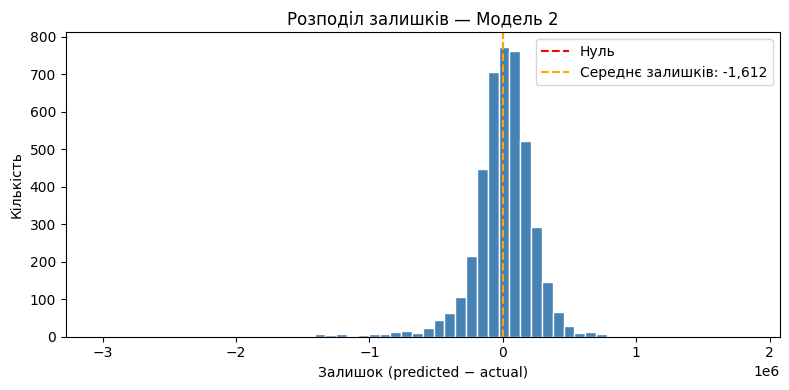


Середнє залишків: -1,611.51


In [14]:
# Бонус — аналіз залишків

residuals = y_pred2 - y_test
 
plt.figure(figsize=(8, 4))
plt.hist(residuals, bins=60, color='steelblue', edgecolor='white')
plt.axvline(x=0, color='red', linestyle='--', linewidth=1.5, label='Нуль')
plt.axvline(x=residuals.mean(), color='orange', linestyle='--',
            linewidth=1.5, label=f'Середнє залишків: {residuals.mean():,.0f}')

plt.xlabel('Залишок (predicted − actual)')
plt.ylabel('Кількість')
plt.title('Розподіл залишків — Модель 2')
plt.legend()
plt.tight_layout()
plt.show()
 
print(f"\nСереднє залишків: {residuals.mean():,.2f}")

**Спостереження:** Залишки розподілені приблизно нормально та центровані біля нуля (середнє ≈ −1 612, що є незначним), проте правосторонній хвіст вказує на систематичне недооцінювання дорогої нерухомості лінійною моделлю.

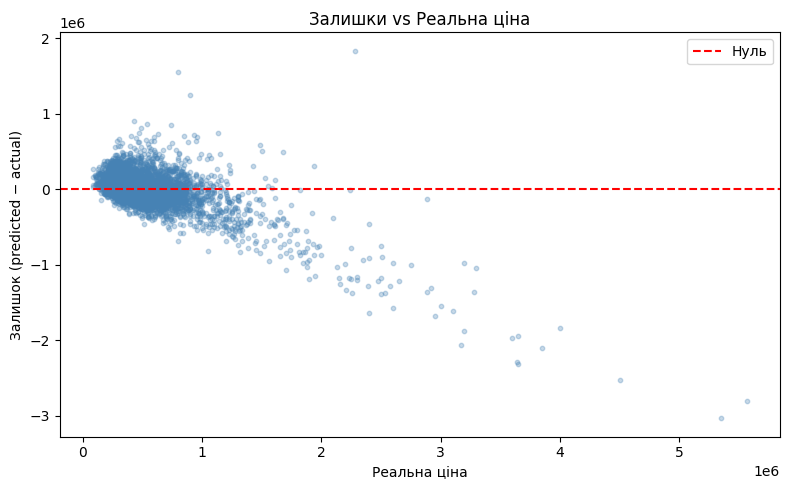

In [15]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, residuals, alpha=0.3, s=10, color='steelblue')
plt.axhline(y=0, color='red', linestyle='--', linewidth=1.5, label='Нуль')
plt.xlabel('Реальна ціна')
plt.ylabel('Залишок (predicted − actual)')
plt.title('Залишки vs Реальна ціна')
plt.legend()
plt.tight_layout()
plt.show()

**Що означав би систематичний ненульовий середній залишок?** Це означало б, що модель постійно помиляється в одну сторону — або завжди завищує, або завжди занижує ціну для всіх будинків.